# 댓글 감성 분석 — 채널 단위 KPI 패널 (이탈 모델 보조지표)

## 데이터 표본 구조
- 구독자 밴드(A/B/C/D) × {이탈/유지} 층화
- 각 층 안에서 채널 랜덤 샘플링
- 채널당 최근 10개 영상 × 영상당 인기 댓글 50개 (≈ 채널당 500개)

표본 구조 특성상 시계열 추세나 채널 이탈 직접 예측은 부적합. 채널 간 비교 가능한 균일 표본으로, **이탈 확률 모델의 보조지표**(해석·검증용 KPI 패널)로 활용한다.

## 적용 방법론 (마케팅·소비자 분석 표준)
1. Net Sentiment Score (NSS)
2. Sentiment Mix (P/Neu/N)
3. Engagement-weighted Sentiment (like_count 가중)
4. Loyalty / Affection Lexicon Score
5. Churn-Warning Lexicon Score
6. Sentiment Polarization
7. Engagement Quality (길이, 이모지/웃음/질문 비율)

## 모델
`cardiffnlp/twitter-xlm-roberta-base-sentiment` — 다국어·SNS 학습·이모지 친화·3-class 분류 (positive/neutral/negative). 자세한 선택 근거는 `docs/comment_sentiment_plan.md` 참고.

## 0. 라이브러리

In [1]:
import os
import re
import html
import glob
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

import emoji
from soynlp.normalizer import repeat_normalize

import torch
import torch.nn.functional as F
from transformers import AutoTokenizer, AutoModelForSequenceClassification

import warnings
warnings.filterwarnings("ignore")

# macOS 한글 폰트
plt.rcParams["font.family"] = "AppleGothic"
plt.rcParams["axes.unicode_minus"] = False

print("라이브러리 로드 완료")

라이브러리 로드 완료


## 1. Lexicon 정의 (Loyalty / Churn-Warning)

마케팅의 VoC 분석에서 쓰는 사전 매칭 방식. `sensitive_keyword_score.ipynb`의 3·2·1 가중치 체계를 차용.

데이터에 맞게 자유롭게 추가/수정 가능 — 모두 단순 부분문자열 매칭이므로 활용형(`-했어요`, `-합니다` 등)을 폭넓게 포함시키는 것이 좋다.

In [2]:
LOYALTY_LEXICON = {
    "충성_고": {  # 명시적 팬덤·관계 표현
        "keywords": ["사랑해요", "사랑합니다", "최고예요", "최고입니다", "응원합니다",
                     "응원해요", "구독했어요", "구독하고", "알림설정",
                     "팬이에요", "팬입니다", "덕질"],
        "weight": 3,
    },
    "충성_중": {  # 재방문·재시청 의향
        "keywords": ["다시 봐도", "또 봐요", "또 보러", "회차", "정주행",
                     "기다렸어요", "기다렸습니다", "다음 영상", "다음편"],
        "weight": 2,
    },
    "충성_저": {  # 가벼운 긍정·친밀도
        "keywords": ["좋아요", "잘봤어요", "잘 봤습니다", "감사합니다", "재밌어요",
                     "재밌네요", "굿", "최고", "역시"],
        "weight": 1,
    },
}

CHURN_WARNING_LEXICON = {
    "이탈_고": {  # 명시적 이탈 선언
        "keywords": ["구독 취소", "구취", "언구독", "이제 안 봐요", "이제 안 봅니다",
                     "탈덕", "정 떨어졌", "실망했어요", "실망입니다"],
        "weight": 3,
    },
    "이탈_중": {  # 채널 변화에 대한 불만
        "keywords": ["예전이 좋았", "옛날이 좋았", "재미없어졌", "재미가 없어",
                     "변했어요", "변했네요", "초심", "왜 이래", "퀄리티 떨어"],
        "weight": 2,
    },
    "이탈_저": {  # 업로드 공백·근황 불안
        "keywords": ["언제 올라와", "왜 안 올려", "근황", "어디 갔어", "잠수",
                     "활동 안 하시", "휴재"],
        "weight": 1,
    },
}

def lex_score(text: str, lexicon: dict) -> int:
    """한 댓글 텍스트에 대해 사전 가중치 합 반환."""
    s = 0
    for info in lexicon.values():
        for kw in info["keywords"]:
            if kw in text:
                s += info["weight"]
    return s

print("Loyalty 키워드 :", sum(len(v["keywords"]) for v in LOYALTY_LEXICON.values()))
print("Churn   키워드 :", sum(len(v["keywords"]) for v in CHURN_WARNING_LEXICON.values()))

Loyalty 키워드 : 30
Churn   키워드 : 25


## 2. 댓글 CSV 일괄 로드

파일명 패턴 `{CHxxx}_{video_index}_{youtube_channel_id}_{youtube_video_id}.csv` 에서 `channel_id`(UC...)를 파싱하여 부착.

In [3]:
COMMENT_DIR = Path("../../data/raw/comments")

# YouTube channel_id는 정확히 24자(UC + 22), video_id는 정확히 11자.
# greedy 매칭 방지 위해 길이 고정.
FNAME_RE = re.compile(
    r"^(CH\d+)_(\d+)_(UC[A-Za-z0-9_-]{22})_([A-Za-z0-9_-]{11})\.csv$"
)

def parse_filename(fname: str):
    m = FNAME_RE.match(fname)
    if not m:
        return None
    return {
        "channel_code": m.group(1),
        "video_index": int(m.group(2)),
        "channel_id": m.group(3),
        "youtube_video_id": m.group(4),
    }

rows = []
skipped = 0
for band_dir in sorted(COMMENT_DIR.glob("band_*")):
    band = band_dir.name.split("_")[-1]  # 'A' / 'B' / 'C' / 'D'
    for csv_path in band_dir.glob("*.csv"):
        meta = parse_filename(csv_path.name)
        if meta is None:
            skipped += 1
            continue
        try:
            df = pd.read_csv(csv_path)
        except Exception as e:
            skipped += 1
            continue
        df["band"] = band
        df["channel_id"] = meta["channel_id"]
        df["channel_code"] = meta["channel_code"]
        df["video_index"] = meta["video_index"]
        rows.append(df)

comments = pd.concat(rows, ignore_index=True)
print(f"파일 스킵   : {skipped}")
print(f"총 댓글 수  : {len(comments):,}")
print(f"채널 수     : {comments['channel_id'].nunique()}")
print(f"영상 수     : {comments.groupby(['channel_id','video_id']).ngroups}")
print(f"밴드별 댓글 :\n{comments['band'].value_counts().sort_index()}")
print(f"channel_id 길이 분포: {comments['channel_id'].str.len().value_counts().to_dict()}")
comments.head(3)

파일 스킵   : 0
총 댓글 수  : 79,937
채널 수     : 226
영상 수     : 2161
밴드별 댓글 :
band
A    16615
B    19861
C    21437
D    22024
Name: count, dtype: int64
channel_id 길이 분포: {24: 79937}


,video_id,video_published_at,comment_index,id,parent,is_reply,parent_is_uploader,text,author_id,author_is_uploader,author_is_verified,like_count,timestamp,is_favorited,is_pinned,band,channel_id,channel_code,video_index
0,vSFNztJKFQ8,2025-10-31 09:01:50,0,UgzRsDCMb82wvCgvnFB4AaABAg,root,False,False,조성민 농구하는거만 봐도 흐뭇하네요 ㅎㅎ,UCXx4MIEh8GCBlGjUgrTeu_Q,False,False,29,2025-11-19 00:00:00,False,False,A,UCGfYw3aUYipiJBe56KdTzMg,CH03773,9
1,vSFNztJKFQ8,2025-10-31 09:01:50,1,UgytTzI2jnr9GMx0oF94AaABAg,root,False,False,조성민 진짜 현역때 비해 10프로도 안뛰는데도 농구 개쉽게하네,UCMcHUx6JW8qRnp1xTur-2pw,False,False,29,2025-11-19 00:00:00,False,False,A,UCGfYw3aUYipiJBe56KdTzMg,CH03773,9
2,vSFNztJKFQ8,2025-10-31 09:01:50,2,UgxSfl1tA4fj6e-1-uh4AaABAg,root,False,False,자삥 얻었다고 사과하는 조슛 ㄷㄷ 인성이 남다르네 같이 사진 찍어준 첫번째 프로선수...,UCKjPez6zTBtZGPx7-Ks58Lw,False,False,18,2025-11-19 00:00:00,False,False,A,UCGfYw3aUYipiJBe56KdTzMg,CH03773,9


## 3. 댓글 전처리 (감성 신호 보존 중심)

- HTML entity 복원
- URL 제거
- 이모지 → `:emoji_name:` 텍스트 변환 (`emoji.demojize`)
- 반복 문자 축약 (`soynlp.repeat_normalize`)
- 초성/밈 표현 치환 (최소한)
- 공백 정리

원본은 `comment_raw` 컬럼으로 보존, 모델 입력은 `comment_clean`.

In [4]:
SLANG_DICT = {
    "ㅇㅈ": "인정",
    "ㄷㄷ": "놀람",
    "ㅁㅊ": "미쳤다",
    "개웃": "매우 웃김",
}

def preprocess_comment(text):
    text = str(text)
    text = html.unescape(text)                       # HTML entity 복원
    text = re.sub(r"http\S+|www\S+", " ", text)    # URL 제거
    text = emoji.demojize(text, language="en")      # 이모지 텍스트 변환
    text = repeat_normalize(text, num_repeats=2)     # 반복 문자 축약
    for k, v in SLANG_DICT.items():                  # 초성/밈 치환
        text = text.replace(k, v)
    text = re.sub(r"\s+", " ", text).strip()        # 공백 정리
    return text

comments["comment_raw"] = comments["text"]
tqdm.pandas(desc="preprocess")
comments["comment_clean"] = comments["text"].progress_apply(preprocess_comment)

# 빈 문자열은 모델 입력 시 문제될 수 있으니 공백 1개로 치환
comments.loc[comments["comment_clean"].str.len() == 0, "comment_clean"] = " "

print(comments[["comment_raw", "comment_clean"]].head(3).to_string())

preprocess:   0%|          | 0/79937 [00:00<?, ?it/s]

                                                 comment_raw                                              comment_clean
0                                     조성민 농구하는거만 봐도 흐뭇하네요 ㅎㅎ                                     조성민 농구하는거만 봐도 흐뭇하네요 ㅎㅎ
1                         조성민 진짜 현역때 비해 10프로도 안뛰는데도 농구 개쉽게하네                         조성민 진짜 현역때 비해 10프로도 안뛰는데도 농구 개쉽게하네
2  자삥 얻었다고 사과하는 조슛 ㄷㄷ 인성이 남다르네 같이 사진 찍어준 첫번째 프로선수라서 기억에 오래남네  자삥 얻었다고 사과하는 조슛 놀람 인성이 남다르네 같이 사진 찍어준 첫번째 프로선수라서 기억에 오래남네


## 4. 감성 모델 로드 (`cardiffnlp/twitter-xlm-roberta-base-sentiment`)

device 자동 감지: **MPS (Apple Silicon) → CUDA → CPU** 순.
최초 1회는 HuggingFace에서 모델(~1.1GB)을 다운로드한다.

In [5]:
MODEL_NAME = "cardiffnlp/twitter-xlm-roberta-base-sentiment"

if torch.backends.mps.is_available():
    DEVICE = "mps"
elif torch.cuda.is_available():
    DEVICE = "cuda"
else:
    DEVICE = "cpu"
print(f"DEVICE = {DEVICE}")

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME).to(DEVICE)
model.eval()

ID2LABEL = {i: l.lower() for i, l in model.config.id2label.items()}
print("id2label :", ID2LABEL)

DEVICE = mps


id2label : {0: 'negative', 1: 'neutral', 2: 'positive'}


## 5. 댓글 단위 batch inference

- `max_length=256`, `batch_size=32` (메모리에 따라 조정)
- 출력: `sentiment_label ∈ {positive, neutral, negative}` + `sentiment_score`
  - `sentiment_score`: 가중 점수 — positive면 +conf, negative면 -conf, neutral이면 0

In [6]:
BATCH_SIZE = 64
MAX_LEN = 128

@torch.inference_mode()
def predict_sentiment(texts, batch_size=BATCH_SIZE, max_length=MAX_LEN):
    labels = []
    scores = []
    for i in tqdm(range(0, len(texts), batch_size), desc="inference"):
        batch = texts[i:i+batch_size]
        enc = tokenizer(batch, padding=True, truncation=True,
                        max_length=max_length, return_tensors="pt").to(DEVICE)
        logits = model(**enc).logits
        probs = F.softmax(logits, dim=-1).cpu().numpy()
        pred = probs.argmax(axis=-1)
        for p, prob in zip(pred, probs):
            label = ID2LABEL[int(p)]
            conf = float(prob[p])
            if label == "positive":
                s = conf
            elif label == "negative":
                s = -conf
            else:
                s = 0.0
            labels.append(label)
            scores.append(s)
    return labels, scores

# === 분석 범위 ===
# Smoke test 용도로 .head(N)을 쓰고 싶으면 아래 줄을 활성화
# comments = comments.head(100).reset_index(drop=True)

labels, scores = predict_sentiment(comments["comment_clean"].tolist())
comments["sentiment_label"] = labels
comments["sentiment_score"] = scores

print(comments["sentiment_label"].value_counts())
print("평균 sentiment_score:", comments["sentiment_score"].mean().round(4))

inference:   0%|          | 0/1250 [00:00<?, ?it/s]

sentiment_label
positive    50895
negative    15559
neutral     13483
Name: count, dtype: int64
평균 sentiment_score: 0.3445


## 6. Lexicon 매칭 + 보조 feature

원본 텍스트 기준으로 계산:
- Loyalty / Churn-warning lexicon 가중치 합
- 이모지 개수, ㅋㅋ/ㅎㅎ 비율, ㅠㅠ/ㅜㅜ 비율, 물음표·느낌표 플래그, 댓글 길이

In [7]:
RE_LAUGH = re.compile(r"[ㅋㅎ]{2,}")
RE_CRY   = re.compile(r"[ㅠㅜ]{2,}")

raw = comments["comment_raw"].astype(str)

comments["loyalty_raw"]   = raw.apply(lambda t: lex_score(t, LOYALTY_LEXICON))
comments["churn_raw"]     = raw.apply(lambda t: lex_score(t, CHURN_WARNING_LEXICON))
comments["emoji_count"]   = raw.apply(lambda t: sum(1 for c in t if emoji.is_emoji(c)))
comments["laugh_count"]   = raw.apply(lambda t: len(RE_LAUGH.findall(t)))
comments["cry_count"]     = raw.apply(lambda t: len(RE_CRY.findall(t)))
comments["question_flag"] = raw.apply(lambda t: int(("?" in t) or ("？" in t)))
comments["exclaim_flag"]  = raw.apply(lambda t: int(("!" in t) or ("！" in t)))
comments["comment_len"]   = raw.str.len()

print("보조 feature 요약")
print(comments[["loyalty_raw","churn_raw","emoji_count","laugh_count",
                "cry_count","question_flag","exclaim_flag","comment_len"]].describe().round(3))

보조 feature 요약
       loyalty_raw  churn_raw  emoji_count  laugh_count  cry_count  \
count    79937.000  79937.000    79937.000    79937.000  79937.000   
mean         0.152      0.003        0.705        0.174      0.067   
std          0.570      0.076        2.824        0.486      0.309   
min          0.000      0.000        0.000        0.000      0.000   
25%          0.000      0.000        0.000        0.000      0.000   
50%          0.000      0.000        0.000        0.000      0.000   
75%          0.000      0.000        1.000        0.000      0.000   
max         11.000      3.000      337.000       14.000      9.000   

       question_flag  exclaim_flag  comment_len  
count      79937.000     79937.000    79937.000  
mean           0.083         0.156       48.091  
std            0.275         0.362       78.327  
min            0.000         0.000        1.000  
25%            0.000         0.000       16.000  
50%            0.000         0.000       30.000  
75%  

## 7. 영상 단위 집계 (sanity·디버깅용)

최종 산출물은 채널 단위지만, 영상 단위 분포도 한번 확인.

In [8]:
def video_agg(g):
    n = len(g)
    pos = (g["sentiment_label"] == "positive").sum()
    neu = (g["sentiment_label"] == "neutral").sum()
    neg = (g["sentiment_label"] == "negative").sum()
    return pd.Series({
        "n_comments": n,
        "pos_ratio": pos / n,
        "neu_ratio": neu / n,
        "neg_ratio": neg / n,
        "net_sentiment_score": (pos - neg) / n,
    })

video_panel = (comments.groupby(["channel_id", "video_id"], dropna=False)
                       .apply(video_agg, include_groups=False)
                       .reset_index())
print(f"영상 수: {len(video_panel)}")
print(video_panel[["pos_ratio","neu_ratio","neg_ratio","net_sentiment_score"]].describe().round(3))

영상 수: 2161
       pos_ratio  neu_ratio  neg_ratio  net_sentiment_score
count   2161.000   2161.000   2161.000             2161.000
mean       0.624      0.187      0.189                0.436
std        0.227      0.152      0.166                0.367
min        0.000      0.000      0.000               -1.000
25%        0.485      0.080      0.073                0.220
50%        0.640      0.160      0.160                0.500
75%        0.800      0.260      0.260                0.700
max        1.000      1.000      1.000                1.000


## 8. 채널 단위 KPI 패널 집계

최종 산출물. 마케팅 KPI 7종을 모두 채널 단위로 정량화.

In [9]:
def channel_agg(g):
    n = len(g)
    pos = (g["sentiment_label"] == "positive").sum()
    neu = (g["sentiment_label"] == "neutral").sum()
    neg = (g["sentiment_label"] == "negative").sum()
    pos_r, neu_r, neg_r = pos / n, neu / n, neg / n

    # 방법 1: NSS
    nss = (pos - neg) / n

    # 방법 3: like-weighted NSS (좋아요 + 1 smoothing)
    w = g["like_count"].fillna(0).clip(lower=0).astype(float) + 1.0
    w_pos = w[g["sentiment_label"] == "positive"].sum()
    w_neg = w[g["sentiment_label"] == "negative"].sum()
    w_tot = w.sum()
    lw_nss = (w_pos - w_neg) / w_tot if w_tot > 0 else 0.0

    # 방법 4·5: lexicon 정규화 (n × max_weight 3 로 나누고 0~1 클립)
    loyalty = float(np.clip(g["loyalty_raw"].sum() / (n * 3), 0, 1))
    churn   = float(np.clip(g["churn_raw"].sum()   / (n * 3), 0, 1))

    # 방법 6: polarization (P=N=0.5일 때 1)
    polar = 4.0 * pos_r * neg_r

    return pd.Series({
        "n_videos": g["video_id"].nunique(),
        "n_comments": n,
        "net_sentiment_score": round(nss, 4),
        "pos_ratio": round(pos_r, 4),
        "neu_ratio": round(neu_r, 4),
        "neg_ratio": round(neg_r, 4),
        "like_weighted_nss": round(lw_nss, 4),
        "loyalty_score": round(loyalty, 4),
        "churn_warning_score": round(churn, 4),
        "polarization_score": round(polar, 4),
        "avg_comment_len": round(g["comment_len"].mean(), 2),
        "emoji_ratio": round((g["emoji_count"] > 0).mean(), 4),
        "laugh_ratio": round((g["laugh_count"] > 0).mean(), 4),
        "cry_ratio":   round((g["cry_count"]   > 0).mean(), 4),
        "question_ratio": round(g["question_flag"].mean(), 4),
    })

panel = (comments.groupby("channel_id", dropna=False)
                 .apply(channel_agg, include_groups=False)
                 .reset_index())
panel["n_videos"] = panel["n_videos"].astype(int)
panel["n_comments"] = panel["n_comments"].astype(int)

print(f"채널 수: {len(panel)}")
panel.head()

채널 수: 226


,channel_id,n_videos,n_comments,net_sentiment_score,pos_ratio,neu_ratio,neg_ratio,like_weighted_nss,loyalty_score,churn_warning_score,polarization_score,avg_comment_len,emoji_ratio,laugh_ratio,cry_ratio,question_ratio
0,UC-NiIeWEem2yb9Zq-p9glsg,3,3,1.0000,1.0000,0.0000,0.0000,1.0000,0.0000,0.000,0.0000,22.67,0.0000,0.0000,0.0000,0.0000
1,UC-NrO4PMMa8zyMyTBy-nCaA,10,500,0.6620,0.7600,0.1420,0.0980,0.6788,0.0960,0.002,0.2979,51.24,0.3520,0.0320,0.2740,0.0820
2,UC-tf6zl3dN2oTpvdTnBKScA,10,499,0.2745,0.5331,0.2084,0.2585,0.3760,0.0341,0.002,0.5512,29.14,0.2044,0.4529,0.0261,0.0581
3,UC0YPr7SRdmyrMFvtITxyeFg,9,335,0.2716,0.4358,0.4000,0.1642,0.2686,0.0458,0.010,0.2862,30.70,0.1045,0.0836,0.0179,0.1313
4,UC117YBQAv8PiIjKTO9QX2Tg,10,500,0.6300,0.7860,0.0580,0.1560,0.5468,0.0407,0.002,0.4905,42.48,0.2380,0.2440,0.0720,0.0740


## 9. 분포 시각화

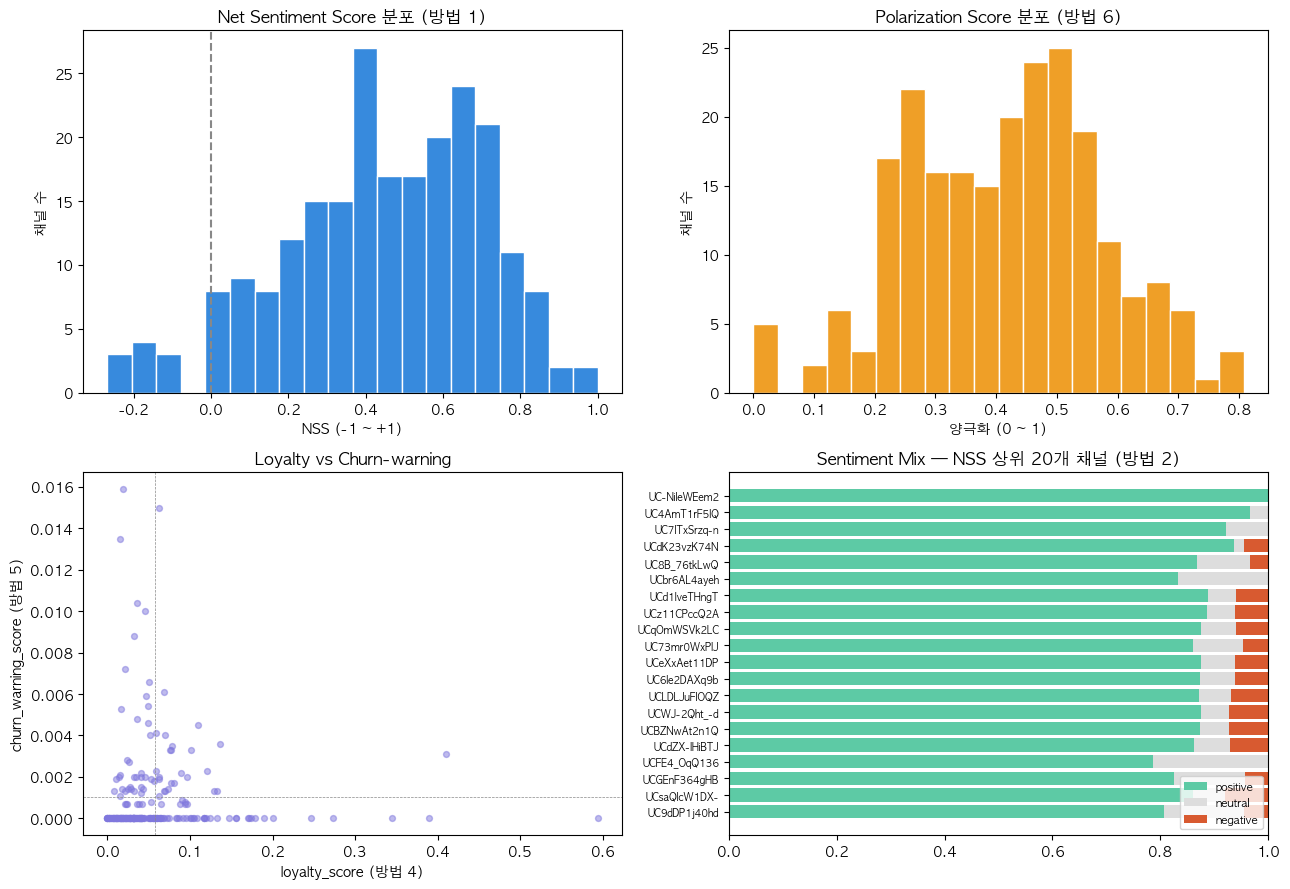

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

# NSS 분포
axes[0,0].hist(panel["net_sentiment_score"], bins=20, color="#378ADD", edgecolor="white")
axes[0,0].axvline(0, color="#888", linestyle="--")
axes[0,0].set_title("Net Sentiment Score 분포 (방법 1)")
axes[0,0].set_xlabel("NSS (-1 ~ +1)")
axes[0,0].set_ylabel("채널 수")

# Polarization 분포
axes[0,1].hist(panel["polarization_score"], bins=20, color="#EF9F27", edgecolor="white")
axes[0,1].set_title("Polarization Score 분포 (방법 6)")
axes[0,1].set_xlabel("양극화 (0 ~ 1)")
axes[0,1].set_ylabel("채널 수")

# Loyalty vs Churn-warning scatter
axes[1,0].scatter(panel["loyalty_score"], panel["churn_warning_score"],
                  alpha=0.5, color="#7F77DD", s=18)
axes[1,0].set_xlabel("loyalty_score (방법 4)")
axes[1,0].set_ylabel("churn_warning_score (방법 5)")
axes[1,0].set_title("Loyalty vs Churn-warning")
axes[1,0].axhline(panel["churn_warning_score"].mean(), color="#888", lw=0.5, linestyle="--")
axes[1,0].axvline(panel["loyalty_score"].mean(),       color="#888", lw=0.5, linestyle="--")

# Sentiment Mix stacked (상위 20개 NSS 채널)
top = panel.sort_values("net_sentiment_score", ascending=True).tail(20)
axes[1,1].barh(range(len(top)), top["pos_ratio"], color="#5DCAA5", label="positive")
axes[1,1].barh(range(len(top)), top["neu_ratio"], left=top["pos_ratio"],
               color="#DDD", label="neutral")
axes[1,1].barh(range(len(top)), top["neg_ratio"],
               left=top["pos_ratio"]+top["neu_ratio"],
               color="#D85A30", label="negative")
axes[1,1].set_yticks(range(len(top)))
axes[1,1].set_yticklabels(top["channel_id"].str.slice(0,12), fontsize=7)
axes[1,1].set_title("Sentiment Mix — NSS 상위 20개 채널 (방법 2)")
axes[1,1].legend(loc="lower right", fontsize=8)
axes[1,1].set_xlim(0, 1)

plt.tight_layout()
plt.show()

이탈 모델과 결합된 채널 수: 226


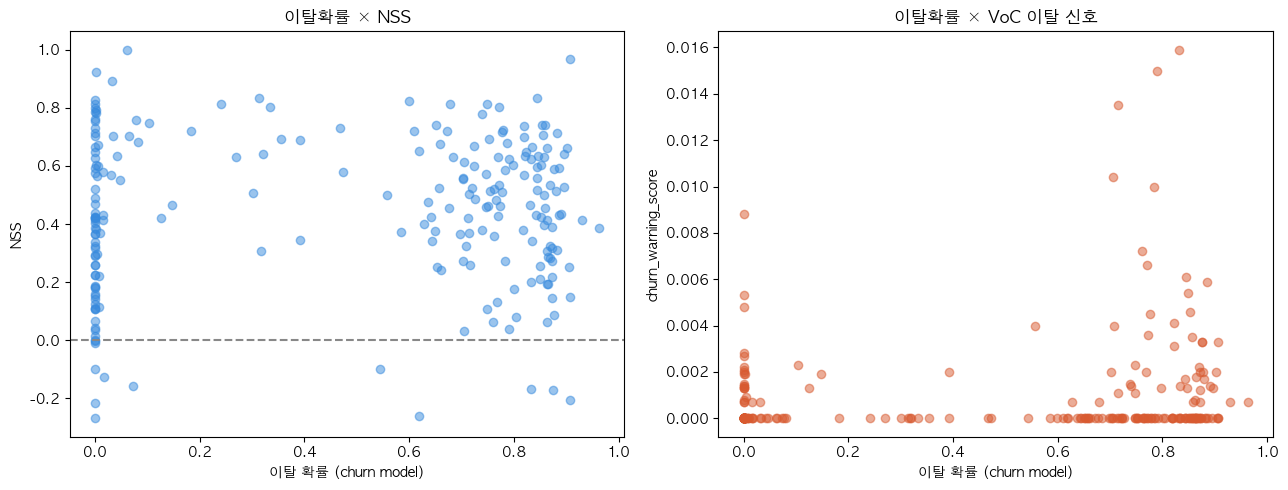

In [11]:
# 이탈 모델 결과와 결합 시각화 (있을 경우)
churn_csv = Path("../../data/raw/churn_probability_output.csv")
if churn_csv.exists():
    churn = pd.read_csv(churn_csv)
    # channel_id 컬럼 자동 탐지
    cid_col = next((c for c in churn.columns if c.lower() in ("channel_id","channelid","id")), None)
    prob_col = next((c for c in churn.columns if "prob" in c.lower() or "churn" in c.lower()), None)
    if cid_col and prob_col:
        merged = panel.merge(churn[[cid_col, prob_col]].rename(
            columns={cid_col:"channel_id", prob_col:"churn_prob"}), on="channel_id", how="inner")
        print(f"이탈 모델과 결합된 채널 수: {len(merged)}")

        fig, axes = plt.subplots(1, 2, figsize=(13, 5))
        axes[0].scatter(merged["churn_prob"], merged["net_sentiment_score"],
                        alpha=0.5, color="#378ADD")
        axes[0].axhline(0, color="#888", linestyle="--")
        axes[0].set_xlabel("이탈 확률 (churn model)")
        axes[0].set_ylabel("NSS")
        axes[0].set_title("이탈확률 × NSS")

        axes[1].scatter(merged["churn_prob"], merged["churn_warning_score"],
                        alpha=0.5, color="#D85A30")
        axes[1].set_xlabel("이탈 확률 (churn model)")
        axes[1].set_ylabel("churn_warning_score")
        axes[1].set_title("이탈확률 × VoC 이탈 신호")
        plt.tight_layout()
        plt.show()
    else:
        print(f"churn 파일은 있으나 채널/확률 컬럼을 자동 탐지하지 못함: {list(churn.columns)}")
else:
    print(f"churn 결과 CSV 미발견: {churn_csv}")

## 10. 저장

`data/raw/comment_sentiment_panel.csv` — 채널 단위 KPI 패널.

In [12]:
OUTPUT_PATH = Path("../../data/raw/comment_sentiment_panel.csv")
panel.to_csv(OUTPUT_PATH, index=False, encoding="utf-8-sig")
print(f"저장 완료: {OUTPUT_PATH}")
print(f"shape: {panel.shape}")

# 무결성 체크
assert panel["channel_id"].str.startswith("UC").all(), "channel_id가 UC로 시작하지 않는 행 존재"
ratio_cols = ["pos_ratio","neu_ratio","neg_ratio","loyalty_score",
              "churn_warning_score","polarization_score",
              "emoji_ratio","laugh_ratio","cry_ratio","question_ratio"]
for c in ratio_cols:
    assert panel[c].between(0, 1).all(), f"{c}가 [0,1] 범위를 벗어남"
diff = (panel["pos_ratio"] + panel["neu_ratio"] + panel["neg_ratio"] - 1).abs()
assert diff.max() < 1e-3, "P+Neu+N != 1"
print("무결성 체크 통과")

저장 완료: ../../data/raw/comment_sentiment_panel.csv
shape: (226, 16)
무결성 체크 통과
